In [1]:
##https://stackabuse.com/hierarchical-clustering-with-python-and-scikit-learn/
##loading the important libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import sklearn.metrics as sm 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.cluster.hierarchy import dendrogram
from scipy.spatial import distance


In [44]:
#dataframe
gtsD_4c = pd.read_csv('data_clusterfinal_2PCA_5Clusters_4foldcodons_gtsdfinal_onlymain_variablesf.csv')
print(gtsD_4c.shape)
print(gtsD_4c.head())
print(gtsD_4c.isnull().sum())
print(gtsD_4c.shape)
print(gtsD_4c.info())



(132, 8)
   substitution_rate  transitions  transversions  \
0          74.609806    28.006129      46.603677   
1         142.305414    70.536261      71.769152   
2          83.162411    49.202247      33.960163   
3          65.430031    16.572012      48.858018   
4          18.118488     4.531154      13.587334   

   T-ending_codon_relative_probability  A-ending_codon_relative_probability  \
0                             0.116233                             0.434717   
1                             0.228838                             0.191958   
2                             0.308293                             0.071829   
3                             0.136552                             0.102972   
4                             0.309787                             0.076277   

   G-ending_codon_relative_probability  C-ending_codon_relative_probability  \
0                             0.195939                             0.253111   
1                             0.214453       

In [45]:
print(gtsD_4c.head())

   substitution_rate  transitions  transversions  \
0          74.609806    28.006129      46.603677   
1         142.305414    70.536261      71.769152   
2          83.162411    49.202247      33.960163   
3          65.430031    16.572012      48.858018   
4          18.118488     4.531154      13.587334   

   T-ending_codon_relative_probability  A-ending_codon_relative_probability  \
0                             0.116233                             0.434717   
1                             0.228838                             0.191958   
2                             0.308293                             0.071829   
3                             0.136552                             0.102972   
4                             0.309787                             0.076277   

   G-ending_codon_relative_probability  C-ending_codon_relative_probability  \
0                             0.195939                             0.253111   
1                             0.214453                

In [46]:
gtsD_4cf = gtsD_4c.drop(['nucleotide_position'], axis=1)

In [47]:
X = gtsD_4cf.values

In [48]:
#Checking the datadrame is not empty and standarize
if X.shape[0] == 0:
    print("Error: No rows in the dataframe after filtering and selecting.")
else:
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X) ##X represents the data matrix

In [49]:
#PCA
pca = PCA(n_components=2)  # Set the number of components you want
principal_components = pca.fit_transform(X_scaled)
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
##'PC1', 'PC2', 'PC3', 'PC4', 'PC5'

In [50]:
#Create a dataframe containing explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
components_df = pd.DataFrame({'Principal Component': ['PC1', 'PC2'],
                              'Explained Variance Ratio': explained_variance_ratio})

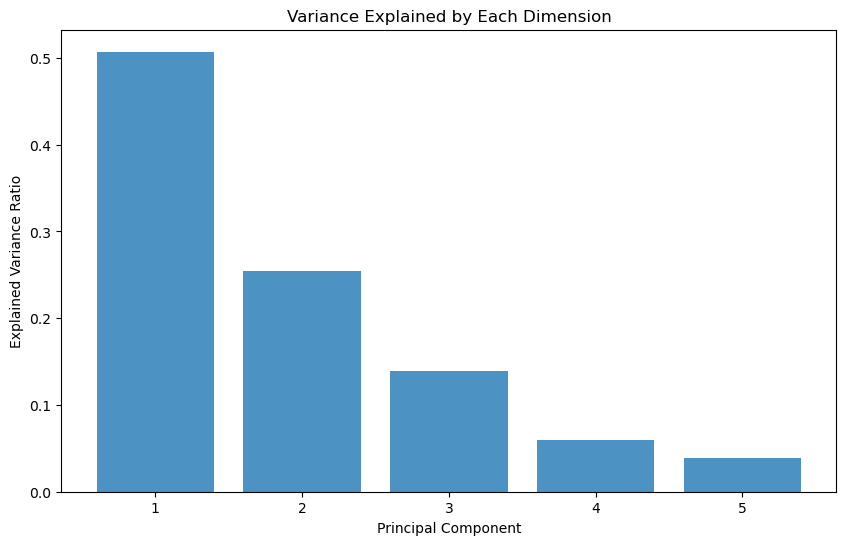

In [12]:
#Calculate explained variance for each component
explained_variance = pca.explained_variance_ratio_

# Plot bar plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, align='center', alpha=0.8)
plt.title('Variance Explained by Each Dimension')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(explained_variance) + 1))
#plt.grid(axis='y')
plt.savefig('variance _explained_gtsd_4fold__5PCAfinal.png', dpi=600)
plt.show()  


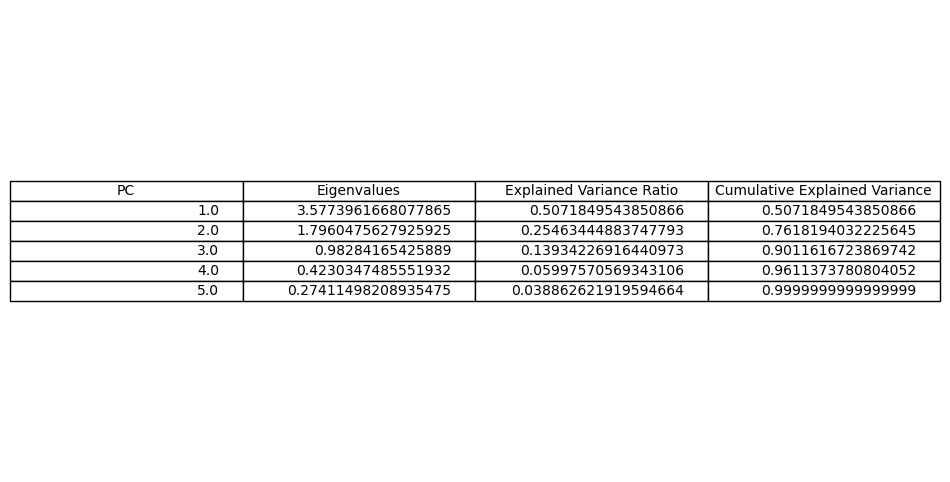

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
# Create DataFrame
eigen_df = pd.DataFrame({
    'PC': range(1, pca.n_components_ + 1),
    'Eigenvalues': pca.explained_variance_,
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Explained Variance': np.cumsum(pca.explained_variance_ratio_)
})

#Convert DataFrame to a table
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=eigen_df.values, colLabels=eigen_df.columns, loc='center')

#Styling the table
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

#Save the figure as PNG
plt.savefig('eigenvalues_gtsD_4fold_finaltable.png', bbox_inches='tight', pad_inches=0.05)
plt.show()

In [14]:
# Eigenvalues
eigenvalues = pca.explained_variance_
print("Eigenvalues:")
print(eigenvalues)

Eigenvalues:
[3.57739617 1.79604756 0.98284165 0.42303475 0.27411498]


In [51]:
# Run hierarchical clustering on the principal components with Ward linkage
n_clusters = 5
clustering = AgglomerativeClustering(n_clusters=n_clusters, metric ='euclidean', linkage='ward')  # Set the number of clusters and linkage method
cluster_labels = clustering.fit_predict(principal_df)




In [52]:
import pandas as pd
from sklearn.cluster import AgglomerativeClustering


# Create a DataFrame with the cluster labels
cluster_df = pd.DataFrame({'Individual': range(len(cluster_labels)),
                           'Cluster': cluster_labels,
                          'nucleotide_position': gtsD_4c['nucleotide_position'],
                           'substitution_rate': gtsD_4c['substitution_rate']
                          })

# Display the DataFrame
print(cluster_df)

csv_clusters=cluster_df


csv_file_path = 'gtsD_cluster_positions_4fold_5clusters_2PCA.csv'
csv_clusters.to_csv(csv_file_path, index=False)


     Individual  Cluster  nucleotide_position  substitution_rate
0             0        0                   27          74.609806
1             1        2                  111         142.305414
2             2        3                  207          83.162411
3             3        0                  246          65.430031
4             4        0                  282          18.118488
..          ...      ...                  ...                ...
127         127        3                  981          13.267620
128         128        2                 1032         162.156282
129         129        4                 1038         193.088866
130         130        1                 1083         222.610827
131         131        2                 1101         258.585291

[132 rows x 4 columns]


In [53]:
loadings = pca.components_

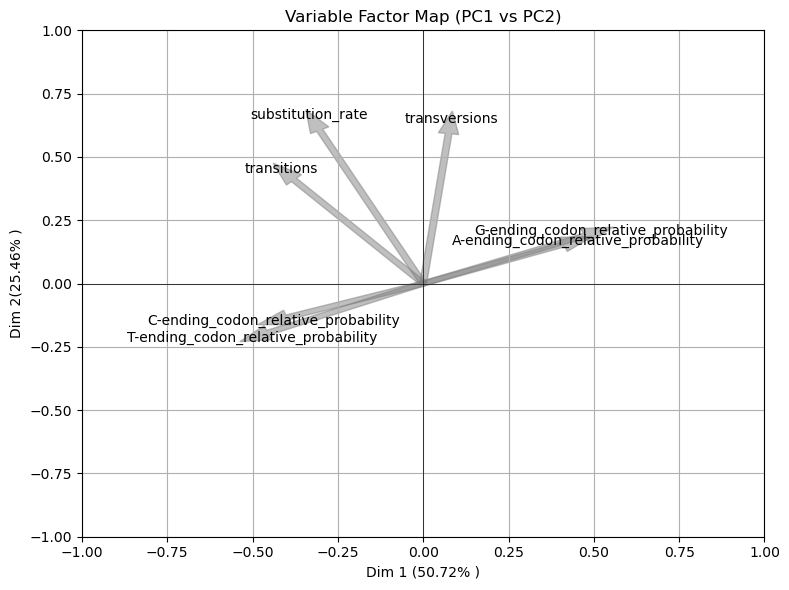

In [54]:

# Variable names
variable_names = ['substitution_rate',  'transitions', 'transversions','T-ending_codon_relative_probability', 'A-ending_codon_relative_probability', 'G-ending_codon_relative_probability', 'C-ending_codon_relative_probability']
# Plot the variable factor map
plt.figure(figsize=(8, 6))
for i in range(loadings.shape[1]):  # Iterate over variables
    plt.arrow(0, 0, loadings[0, i], loadings[1, i], color='gray', alpha=0.5, width=0.02)  # Plot arrow for PC1 and PC2
    plt.text(loadings[0, i] * 1.1, loadings[1, i] * 1.1, variable_names[i], color='black', ha='center', va='center')  # Label variable
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel(f'Dim 1 ({explained_variance_ratio[0]*100:.2f}% )')
plt.ylabel(f'Dim 2({explained_variance_ratio[1]*100:.2f}% )')
plt.title('Variable Factor Map (PC1 vs PC2)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
#Adjust layout to ensure all labels are included
plt.tight_layout()

#Save the plot to PNG
plt.savefig('loadings_gtsD_4fold_plot_2pc.png', dpi=600)
plt.show()  


In [55]:
#Add cluster labels to the dataframe
principal_df['cluster'] = cluster_labels

In [56]:

variable_values = gtsD_4c['nucleotide_position'].values

#plot principal components
plt.figure(figsize=(10, 6))






<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

C:\Users\user\AppData\Local\Temp\ipykernel_13400\3911040823.py:13: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  sns.scatterplot(x='PC1', y='PC2', data=principal_df, hue=cluster_labels, palette=custom_order, legend='full')


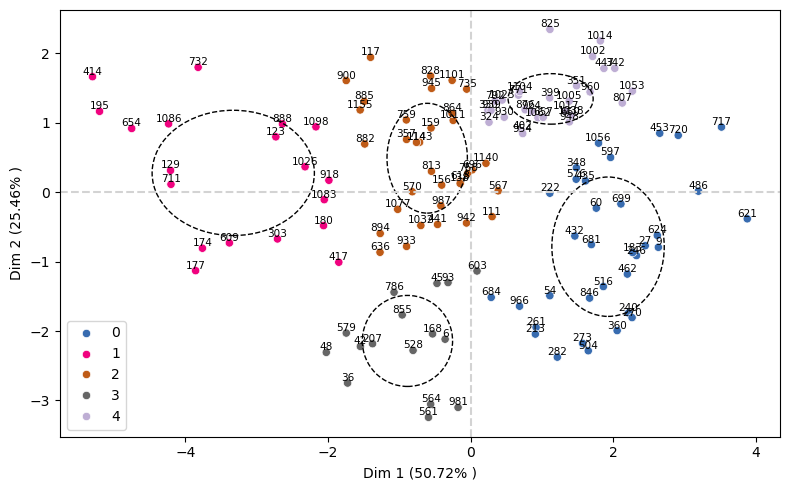

In [57]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

#Default "Paired" palette with 12 colors
paired_palette = sns.color_palette("Accent", 12)

#colors order
custom_order = [paired_palette[i] for i in [4, 5, 6, 7, 1, 2, 3, 0, 8]]

plt.figure(figsize=(8, 5))
sns.scatterplot(x='PC1', y='PC2', data=principal_df, hue=cluster_labels, palette=custom_order, legend='full')

plt.title('')
plt.xlabel(f'Dim 1 ({explained_variance_ratio[0]*100:.2f}% )')
plt.ylabel(f'Dim 2 ({explained_variance_ratio[1]*100:.2f}% )')
# Add a dashed line at (0, 0)
plt.axhline(0, color='LightGray', linestyle='--')
plt.axvline(0, color='LightGray', linestyle='--')


#Add ellipses around each cluster of dots
for cluster in principal_df['cluster'].unique():
    cluster_data = principal_df[principal_df['cluster'] == cluster]
    ellipse = Ellipse(xy=(cluster_data['PC1'].mean(), cluster_data['PC2'].mean()), width=cluster_data['PC1'].std() * 2, height=cluster_data['PC2'].std() * 2, edgecolor='black', linestyle='--', fill=False)
    plt.gca().add_patch(ellipse)

#Add labels to each point
for i, txt in enumerate(variable_values):
    plt.text(principal_components[i, 0], principal_components[i, 1], txt, fontsize=7.5, ha='center', va='bottom')


#Adjust layout to ensure all labels are included
plt.tight_layout()

#Save the plot to PNG
plt.savefig('gtsD_4fold_4clusters_2pca_2t.png', dpi=600)
plt.show()  




In [58]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)  # X is the data matrix



In [59]:
# Perform hierarchical clustering on principal components with Ward method
Z = linkage(principal_components, method='ward')



In [60]:

principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])



In [61]:
cluster_labels = clustering.fit_predict(principal_df)



In [62]:
sites_labels =gtsD_4c['nucleotide_position']


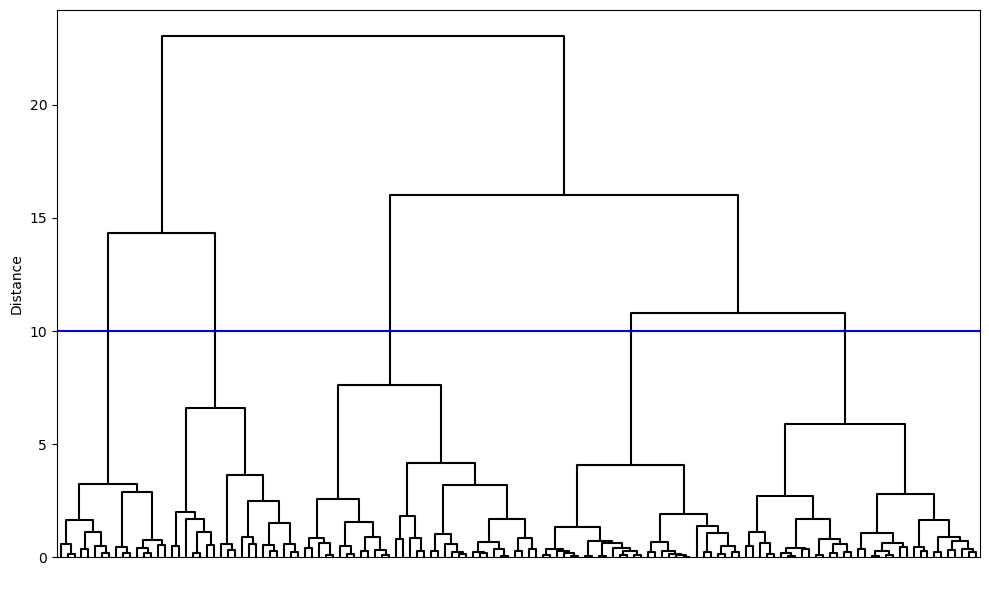

In [63]:

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(10, 6))

dendrogram1 = dendrogram(linkage(principal_components, method='ward'), show_contracted=False, link_color_func=lambda x: 'black')



plt.title('')
plt.ylabel('Distance')

plt.axhline (y=10, color = 'b', linestyle = '-')


  # Adjust layout to ensure all labels are included
plt.tight_layout()

# Set x-axis tick parameters to white
plt.xticks(color='white')  # Change color of x-axis ticks to white
# Save the plot to PNG
plt.savefig('Dendrogram_gtsD_4fold_5groups_2PCA.png', dpi=600)
plt.show()  


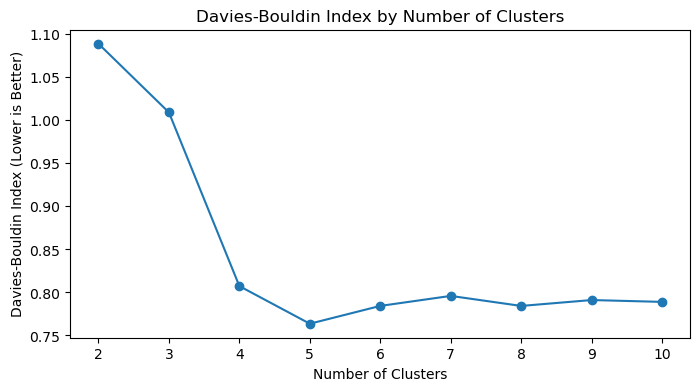

In [64]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import davies_bouldin_score

# Range of cluster numbers to try
range_n_clusters = range(2, 11)

# List to store Davies-Bouldin Index scores
db_scores = []

for n_clusters in range_n_clusters:
    # Initialize AgglomerativeClustering with Ward linkage
    clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    cluster_labels = clusterer.fit_predict(principal_df)  # Replace principal_df with your data variable
    
    # Compute the Davies-Bouldin Index
    db_score = davies_bouldin_score(principal_df, cluster_labels)
    db_scores.append(db_score)

#plot the Davies-Bouldin Index scores
plt.figure(figsize=(8, 4))
plt.plot(range_n_clusters, db_scores, marker='o')

#Improve x-axis 
plt.xticks(range_n_clusters)

#Add title and labels
plt.title('Davies-Bouldin Index by Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Index (Lower is Better)')

#Save the plot to PNG
plt.savefig('davies_bouldin_score_gtsD_4fold.png', dpi=600)
plt.show()  
